In [ ]:
import os
import re
import ast
import math
import json
import copy
import random
import warnings
from collections import Counter, deque
from typing import Iterable, Dict, Set, Tuple, List, Optional,Union
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx
import obonet

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
import sys

sys.path.insert(0, str((Path.cwd().parent / "src").resolve()))

assert (Path.cwd().parent / "src" / "utils_corrected.py").exists()

from utils_corrected import (
    compute_ensemble_probs, predict_without_MCD,
    chunked_mad_over_runs, build_pred_annots_dict, load_kfold_ensembles, PFP
)


In [7]:
RNA_associated_TM_Vec = np.load("../data/RNA_associated_proteins_TM_Vec.npy", allow_pickle=True)
RNA_associated_proteins_df = pd.read_csv("../data/RNA_associated_proteins.tsv", sep="\t")
embedding_dict = {} 
for i in range(len(RNA_associated_TM_Vec)):
    embedding_dict[RNA_associated_proteins_df.iloc[i]['source_id']] = RNA_associated_TM_Vec[i]

print(len(embedding_dict))

353


In [5]:
#get the child terms for a given term

def load_go_graph(
    obo_path: str,
    relations: Iterable[str] = ("is_a", "part_of"),
    normalize_alt_ids: bool = True,
) -> Tuple[nx.DiGraph, Dict[str, str]]:
    """
    Load GO-basic.obo with obonet, keep only selected edge relations,
    and return a DiGraph oriented parent -> child so descendants(term)
    = all children-of-children.

    Returns:
      G: nx.DiGraph with edges parent -> child
      id_map: mapping from any alt_id to its primary id (identity if not an alt)
    """
    G_multi = obonet.read_obo(obo_path)  # MultiDiGraph, edges child -> parent
    # Build alt_id map (so queries using an alt id resolve to the primary)
    id_map: Dict[str, str] = {}
    for node, data in G_multi.nodes(data=True):
        id_map[node] = node
        for alt in data.get("alt_id", []):
            id_map[alt] = node

    # Create filtered DiGraph with direction flipped to parent -> child
    G = nx.DiGraph()
    # copy nodes & attrs
    G.add_nodes_from((n, d) for n, d in G_multi.nodes(data=True))

    keep = set(relations)
    for u, v, _k, edata in G_multi.edges(keys=True, data=True):
        rel = edata.get("relation", "is_a")
        if rel in keep:
            # In obonet: u -> v means u is_a/part_of v (child -> parent)
            # Flip so returns parent -> child
            G.add_edge(v, u, relation=rel)
    return G, id_map


def normalize_id(go_id: str, id_map: Dict[str, str]) -> str:
    return id_map.get(go_id, go_id)


def get_all_descendants(
    go_id: str,
    G: nx.DiGraph,
    id_map: Optional[Dict[str, str]] = None,
) -> List[str]:
    """
    Return ALL descendants (transitive children) of go_id under the relations used to build G.
    """
    q = normalize_id(go_id, id_map) if id_map is not None else go_id
    if q not in G:
        return []
    # Since oriented edges parent -> child:
    return sorted(nx.descendants(G, q))


def get_direct_children(
    go_id: str,
    G: nx.DiGraph,
    id_map: Optional[Dict[str, str]] = None,
) -> List[str]:
    """Return only immediate children of go_id."""
    q = normalize_id(go_id, id_map) if id_map is not None else go_id
    if q not in G:
        return []
    return sorted(G.successors(q))



In [31]:
# go_obo = "../data/go-basic.obo"
# G, id_map = load_go_graph(go_obo, relations=("is_a", "part_of"))

# RNA_binding_term = "GO:0003723"  # biological_process
# RNA_binding_all_kids = get_all_descendants(RNA_binding_term, G, id_map)     

# nucleic_acid_binding_term = "GO:0003676"
# nucleic_acid_binding_all_kids = get_all_descendants(nucleic_acid_binding_term, G, id_map)     
# print(len(RNA_binding_all_kids), "descendants")

# catalytic_activity_acting_on_rna_term = "GO:0140098"
# catalytic_activity_acting_on_rna_all_kids = get_all_descendants(catalytic_activity_acting_on_rna_term, G, id_map)    
# print(len(catalytic_activity_acting_on_rna_all_kids), "descendants")

# mrna_metabolic_process_term = "GO:0016071"
# mrna_metabolic_process_all_kids = get_all_descendants(mrna_metabolic_process_term, G, id_map)     
# print(len(mrna_metabolic_process_all_kids), "descendants")

# rna_processing_term = "GO:0006396"
# rna_processing_all_kids = get_all_descendants(rna_processing_term, G, id_map)     
# print(len(rna_processing_all_kids), "descendants")

# ribosome_term = "GO:0005840"
# ribosome_all_kids = get_all_descendants(ribosome_term, G, id_map)     
# print(len(ribosome_all_kids), "descendants")

In [32]:
# #sanity check the root terms
# mf_root_term = "GO:0003674"
# mf_root_all_kids = get_all_descendants(mf_root_term, G, id_map)     
# print(len(mf_root_all_kids), "descendants")

# bp_root_term = "GO:0008150"
# bp_root_all_kids = get_all_descendants(bp_root_term, G, id_map)     
# print(len(bp_root_all_kids), "descendants")

# cc_root_term = "GO:0005575"
# cc_root_all_kids = get_all_descendants(cc_root_term, G, id_map)     
# print(len(cc_root_all_kids), "descendants")

In [12]:
#read in TUNED_MODEL_ARCHS.json
with open('../data/TUNED_MODEL_ARCHS.json') as f:
    TUNED_MODEL_ARCHS = json.load(f)

In [13]:
MF_CHOSEN_CONFIG = TUNED_MODEL_ARCHS['MFO']['CHOSEN_CONFIG']
MF_CHOSEN_CONFIG_ARCH = TUNED_MODEL_ARCHS['MFO']['CHOSEN_CONFIG_ARCH']
MF_CHOSEN_CONFIG_LOSS = 'Balanced'
MF_CHOSEN_LEARNING_RATE = TUNED_MODEL_ARCHS['MFO']['CHOSEN_CONFIG_LR']
MF_CHOSEN_NUM_CLASSES = TUNED_MODEL_ARCHS['MFO']['NUM_CLASSES']
MF_dropout_rate   = 0.3
MF_hidden_dims    = MF_CHOSEN_CONFIG_ARCH
MF_input_dim      = 512
MF_output_dim     = MF_CHOSEN_NUM_CLASSES
MF_device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# MF_base_kwargs should match what PFP expects, e.g. {"input_dim":..., "hidden_dims":..., ...}
MF_base_kwargs    = {
    'input_dim'   : MF_input_dim,
    'hidden_dims' : MF_hidden_dims,
    'output_dim'  : MF_output_dim,
    'dropout_rate': MF_dropout_rate,
}

BP_CHOSEN_CONFIG = TUNED_MODEL_ARCHS['BPO']['CHOSEN_CONFIG']
BP_CHOSEN_CONFIG_ARCH = TUNED_MODEL_ARCHS['BPO']['CHOSEN_CONFIG_ARCH']
BP_CHOSEN_CONFIG_LOSS = 'Balanced'
BP_CHOSEN_LEARNING_RATE = TUNED_MODEL_ARCHS['BPO']['CHOSEN_CONFIG_LR']
BP_CHOSEN_NUM_CLASSES = TUNED_MODEL_ARCHS['BPO']['NUM_CLASSES']
BP_dropout_rate   = 0.3
BP_hidden_dims    = BP_CHOSEN_CONFIG_ARCH
BP_input_dim      = 512
BP_output_dim     = BP_CHOSEN_NUM_CLASSES
BP_device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BP_base_kwargs should match what PFP expects, e.g. {"input_dim":..., "hidden_dims":..., ...}
BP_base_kwargs    = {
    'input_dim'   : BP_input_dim,
    'hidden_dims' : BP_hidden_dims,
    'output_dim'  : BP_output_dim,
    'dropout_rate': BP_dropout_rate,
}

CC_CHOSEN_CONFIG = TUNED_MODEL_ARCHS['CCO']['CHOSEN_CONFIG']
CC_CHOSEN_CONFIG_ARCH = TUNED_MODEL_ARCHS['CCO']['CHOSEN_CONFIG_ARCH']
CC_CHOSEN_CONFIG_LOSS = 'Balanced'
CC_CHOSEN_LEARNING_RATE = TUNED_MODEL_ARCHS['CCO']['CHOSEN_CONFIG_LR']
CC_CHOSEN_NUM_CLASSES = TUNED_MODEL_ARCHS['CCO']['NUM_CLASSES']
CC_dropout_rate   = 0.3
CC_hidden_dims    = CC_CHOSEN_CONFIG_ARCH
CC_input_dim      = 512
CC_output_dim     = CC_CHOSEN_NUM_CLASSES
CC_device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# CC_base_kwargs should match what PFP expects, e.g. {"input_dim":..., "hidden_dims":..., ...}
CC_base_kwargs    = {
    'input_dim'   : CC_input_dim,
    'hidden_dims' : CC_hidden_dims,
    'output_dim'  : CC_output_dim,
    'dropout_rate': CC_dropout_rate,
}

MF_root_dir     = r"../data/trained_PlasmoFP_models/mf_publish"
BP_root_dir     = r"../data/trained_PlasmoFP_models/bp_publish"
CC_root_dir     = r"../data/trained_PlasmoFP_models/cc_publish"

MF_kf_root      = os.path.join(MF_root_dir, "k_folds")
BP_kf_root      = os.path.join(BP_root_dir, "k_folds")
CC_kf_root      = os.path.join(CC_root_dir, "k_folds")

MF_fold_options = [20]
BP_fold_options = [20]
CC_fold_options = [20]

MF_raw_ensembles = load_kfold_ensembles(
    kf_root=MF_kf_root,
    fold_options=MF_fold_options,
    model_cls=PFP,
    model_kwargs=MF_base_kwargs,
    device=MF_device
)
BP_raw_ensembles = load_kfold_ensembles(
    kf_root=BP_kf_root,
    fold_options=BP_fold_options,
    model_cls=PFP,
    model_kwargs=BP_base_kwargs,
    device=BP_device
)
CC_raw_ensembles = load_kfold_ensembles(
    kf_root=CC_kf_root,
    fold_options=CC_fold_options,
    model_cls=PFP,
    model_kwargs=CC_base_kwargs,
    device=CC_device
)

In [16]:
def run_inference_on_embedding_dict(
    embedding_dict: Dict[str, np.ndarray],          # {source_id: (D,)}
    aspect_to_ensembles: dict,                      # {"MF": ..., "BP": ..., "CC": ...}
    *,
    folds_key: int = 20,
    batch_size: int = 512,
    device: Optional[torch.device] = None,
    chunk_size: int = 50,
    save_dir: Optional[Union[str, Path]] = None,    
    species: Optional[str] = None,                  
    return_arrays_too: bool = False,                
):
    """
    Run ensemble inference on a dict of embeddings and return per-ID predictions.

    Returns
    -------
    results : dict
        {
          "MF": {"median": {id: (C,) np.ndarray}, "mad": {id: (C,) np.ndarray}},
          "BP": {...},
          "CC": {...}
        }

    If return_arrays_too is True, also returns:
      id_order: List[str] and array_views: {"MF": {"median": (N,C), "mad": (N,C)}, ...}
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Edge case
    if not embedding_dict:
        empty = {"median": {}, "mad": {}}
        results = {"MF": empty.copy(), "BP": empty.copy(), "CC": empty.copy()}
        if return_arrays_too:
            return results, [], {"MF": {"median": np.zeros((0,0), np.float32),
                                        "mad":    np.zeros((0,0), np.float32)},
                                 "BP": {"median": np.zeros((0,0), np.float32),
                                        "mad":    np.zeros((0,0), np.float32)},
                                 "CC": {"median": np.zeros((0,0), np.float32),
                                        "mad":    np.zeros((0,0), np.float32)}}
        return results

    # 1) Create a stable order of IDs for batching
    id_order: List[str] = sorted(embedding_dict.keys())

    # 2) Stack embeddings (N, D)
    emb_list = []
    for k in id_order:
        v = embedding_dict[k]
        # Ensure shape is (D,) or (1,D)
        if v.ndim == 2 and v.shape[0] == 1:
            v = v[0]
        assert v.ndim == 1, f"Embedding for {k} must be 1D, got shape {v.shape}"
        emb_list.append(v.astype(np.float32, copy=False))
    emb_arr = np.stack(emb_list, axis=0)
    N = emb_arr.shape[0]

    # 3) DataLoader
    loader = DataLoader(
        TensorDataset(torch.from_numpy(emb_arr).float()),
        batch_size=batch_size,
        shuffle=False
    )

    results = {}
    array_views = {}

    for asp, kf_models in aspect_to_ensembles.items():
        # ---- ensemble forward ----
        probs_dict = compute_ensemble_probs(kf_models, loader, device, predict_without_MCD)

        # Pick requested folds_key (fallback to largest key if missing)
        if folds_key in probs_dict:
            probs_stack = probs_dict[folds_key]   # (K, N, C)
        else:
            key = sorted(probs_dict.keys())[-1]
            probs_stack = probs_dict[key]

        # ---- aggregate K runs ----
        median_probs = np.median(probs_stack, axis=0)                          # (N, C)
        mad_probs    = chunked_mad_over_runs(probs_stack, chunk_size=chunk_size)  # (N, C)

        # ---- map back to IDs ----
        median_map = {sid: median_probs[i] for i, sid in enumerate(id_order)}
        mad_map    = {sid: mad_probs[i]    for i, sid in enumerate(id_order)}

        results[asp] = {"median": median_map, "mad": mad_map}
        array_views[asp] = {"median": median_probs, "mad": mad_probs}

        if save_dir is not None and species is not None:
            outdir = Path(save_dir)
            outdir.mkdir(parents=True, exist_ok=True)
            np.save(outdir / f"{species}_{asp}_ids_{folds_key}fold.npy", np.array(id_order, dtype=object))
            np.save(outdir / f"{species}_{asp}_median_{folds_key}fold.npy", median_probs)
            np.save(outdir / f"{species}_{asp}_mad_{folds_key}fold.npy",    mad_probs)

    if return_arrays_too:
        return results, id_order, array_views
    return results


In [20]:
aspect_to_ensembles = {
    "MF": MF_raw_ensembles,
    "BP": BP_raw_ensembles,
    "CC": CC_raw_ensembles,
}

# 0) Run dict-based inference but ALSO get arrays + id_order
preds, id_order, array_views = run_inference_on_embedding_dict(
    embedding_dict=embedding_dict,
    aspect_to_ensembles=aspect_to_ensembles,
    folds_key=20,
    batch_size=512,
    device='cpu',
    chunk_size=50,
    save_dir="genomes_to_annotate_with_PlasmoFP/missing_by_aspect_new_2/ensemble_probs_single",
    species="RNA_assoc_only",
    return_arrays_too=True,
)

# Use the exact same row order the model used:
test_entries = id_order

# 1) Map arrays per aspect (now taken from array_views)
mf_median, mf_mad = array_views["MF"]["median"], array_views["MF"]["mad"]
bp_median, bp_mad = array_views["BP"]["median"], array_views["BP"]["mad"]
cc_median, cc_mad = array_views["CC"]["median"], array_views["CC"]["mad"]

# Sanity check lengths
N = len(test_entries)
assert mf_median.shape[0] == N == bp_median.shape[0] == cc_median.shape[0], \
    f"Row count mismatch: MF {mf_median.shape[0]}, BP {bp_median.shape[0]}, CC {cc_median.shape[0]}, entries {N}"

# 2) Load thresholds and MLBs (unchanged)
eff_thresh = {
    "Function": json.load(open("../data/effective_thresholds_ensemble20_function.json")),
    "Process":  json.load(open("../data/effective_thresholds_ensemble20_process.json")),
    "Component":json.load(open("../data/effective_thresholds_ensemble20_component.json")),
}
# Normalize FDR-string keys → rounded floats
for aspect, term_dict in eff_thresh.items():
    for term, fdr_map in term_dict.items():
        new_map = {}
        for fdr_str, thr in fdr_map.items():
            if thr is not None:
                new_map[round(float(fdr_str), 2)] = thr
        eff_thresh[aspect][term] = new_map

mlb_by_asp = {
    "MF": pickle.load(open("../data/mlbs/function_mlb.pkl", "rb")),
    "BP": pickle.load(open("../data/mlbs/process_mlb.pkl", "rb")),
    "CC": pickle.load(open("../data/mlbs/component_mlb.pkl", "rb")),
}

median_by_asp = {"MF": mf_median, "BP": bp_median, "CC": cc_median}
mad_by_asp    = {"MF": mf_mad,    "BP": bp_mad,    "CC": cc_mad}

asp_to_name = {"MF": "Function", "BP": "Process", "CC": "Component"}
target_fdrs = [0.01, 0.05, 0.10, 0.20, 0.30]

# 3) Threshold just like before
all_predictions = {}
for asp in ["MF", "BP", "CC"]:
    aspect_name  = asp_to_name[asp]
    thresholds   = eff_thresh[aspect_name]
    mlb          = mlb_by_asp[asp]
    median_probs = median_by_asp[asp]  # (N, C) aligned to test_entries
    MAD_probs    = mad_by_asp[asp]     # (N, C) aligned to test_entries

    preds_for_aspect = {}
    for target_fdr in target_fdrs:
        pred_dict = build_pred_annots_dict(
            median_probs, MAD_probs, thresholds,
            test_entries=test_entries,            # IDs aligned to rows of arrays
            terms=list(mlb.classes_),             # column order for (N, C)
            lambda_val=1,                         # use median - 1×MAD internally
            target_fdr=target_fdr
        )
        preds_for_aspect[round(target_fdr, 3)] = pred_dict

    all_predictions[asp] = preds_for_aspect


/opt/anaconda3/envs/NLP/lib/python3.9/site-packages/sklearn/base.py:310: UserWarning: Trying to unpickle estimator MultiLabelBinarizer from version 1.0.2 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
Building predictions: 100%|██████████| 353/353 [00:00<00:00, 382.81it/s]


In [ ]:
function_ancestors_dict = json.load(open("../data/go_term_ancestors/function_ALL_data_ancestors_dict.json"))
process_ancestors_dict = json.load(open("../data/go_term_ancestors/process_ALL_data_ancestors_dict.json"))
component_ancestors_dict = json.load(open("../data/go_term_ancestors/component_ALL_data_ancestors_dict.json"))

function_json_dict = json.load(open("../data/go_term_ancestors/function_ALL_data_json_dict.json"))
process_json_dict = json.load(open("../data/go_term_ancestors/process_ALL_data_json_dict.json"))
component_json_dict = json.load(open("../data/go_term_ancestors/component_ALL_data_json_dict.json"))

anc_dicts = {
    "MF": function_ancestors_dict,
    "BP": process_ancestors_dict,
    "CC": component_ancestors_dict,
}
json_dicts = {
    "MF": function_json_dict,
    "BP": process_json_dict,
    "CC": component_json_dict,
}

In [ ]:
NSP = {"MF": "molecular_function", "BP": "biological_process", "CC": "cellular_component"}

def normalize_id(go: str) -> str:
    return id_map.get(go, go)

obo_descendants = {}  # {asp: {node: set(descendants)}}
for asp, nsp in NSP.items():
    nodes_asp = [n for n, d in G.nodes(data=True) if d.get("namespace") == nsp]
    Gasp = G.subgraph(nodes_asp).copy()
    obo_descendants[asp] = {n: nx.descendants(Gasp, n) for n in Gasp.nodes()}

# 2) Deepest-only selector using OBO descendants (with ID normalization)
def select_deepest_terms_obo(pred_dict, mlb, asp):
    mlb_set = set(map(normalize_id, mlb.classes_))
    desc_cache = obo_descendants[asp]
    out = {}
    for pid, go_scores in pred_dict.items():
        preds = {normalize_id(t): s for t, s in go_scores.items() if normalize_id(t) in mlb_set}
        vkeys = set(preds.keys())
        keep = {}
        for t, s in preds.items():
            if not (desc_cache.get(t, set()) & vkeys):
                keep[t] = s
        out[pid] = keep
    return out

def go_name(go_id: str):
    return json_dicts["MF"].get(go_id, {}).get("name") or json_dicts["BP"].get(go_id, {}).get("name") \
           or json_dicts["CC"].get(go_id, {}).get("name") or G.nodes.get(go_id, {}).get("name", go_id)

def annotate_go_terms(predictions_dict, _ignored_json):
    return {
        pid: {(t, s, go_name(t)) for t, s in term_map.items()}
        for pid, term_map in predictions_dict.items()
    }

def _get_pred_dict(preds_for_aspect, fdr):
    r = round(float(fdr), 3)
    return preds_for_aspect.get(fdr) or preds_for_aspect.get(r) or preds_for_aspect.get(str(fdr)) or preds_for_aspect.get(str(r))

deepest_annotations = {asp: {} for asp in ["MF","BP","CC"]}
for asp, fdr_map in all_predictions.items():  # asp -> {fdr: {protein:{GO:score}}}
    mlb = mlb_by_asp[asp]
    for fdr in target_fdrs:
        pred_dict = _get_pred_dict(fdr_map, fdr)
        if pred_dict is None: 
            continue
        deepest = select_deepest_terms_obo(pred_dict, mlb, asp)
        deepest_annotations[asp][round(float(fdr), 3)] = annotate_go_terms(deepest, None)


In [34]:
list(deepest_annotations['MF'][0.01].keys())[:10]

['PF3D7_0105700.1',
 'PF3D7_0106400.1',
 'PF3D7_0107900.1',
 'PF3D7_0108300.1',
 'PF3D7_0109600.1',
 'PF3D7_0109700.1',
 'PF3D7_0110800.1',
 'PF3D7_0111800.1',
 'PF3D7_0201800.1',
 'PF3D7_0205700.1']

In [35]:
print(deepest_annotations['MF'][0.01]['PF3D7_0110800.1'])
print(deepest_annotations['MF'][0.1]['PF3D7_0110800.1'])
print(deepest_annotations['MF'][0.2]['PF3D7_0110800.1'])
print(deepest_annotations['MF'][0.3]['PF3D7_0110800.1'])

{('GO:0097159', 0.91057265, 'organic cyclic compound binding')}
{('GO:0003676', 0.6627574, 'nucleic acid binding')}
{('GO:0003824', 0.028280556, 'catalytic activity'), ('GO:0036094', 0.029806126, 'small molecule binding'), ('GO:0003676', 0.6627574, 'nucleic acid binding')}
{('GO:0003824', 0.028280556, 'catalytic activity'), ('GO:0043167', 0.019726716, 'ion binding'), ('GO:0003676', 0.6627574, 'nucleic acid binding')}


In [ ]:
# MF_categories: Dict[str, Set[str]] = {
#     "RNA_binding": set(["GO:0003723"]) | set(RNA_binding_all_kids),
#     "nucleic_acid_binding": set(["GO:0003676"]) | set(nucleic_acid_binding_all_kids),
#     "catalytic_activity_acting_on_RNA": set(["GO:0140098"]) | set(catalytic_activity_acting_on_rna_all_kids),
# }

# BP_categories: Dict[str, Set[str]] = {
#     "mRNA_metabolic_process": set(["GO:0016071"]) | set(mrna_metabolic_process_all_kids),
#     "RNA_processing": set(["GO:0006396"]) | set(rna_processing_all_kids),
# }

# CC_categories: Dict[str, Set[str]] = {
#     "ribosome": set(["GO:0005840"]) | set(ribosome_all_kids),
# }

# ASP_TO_CATS = {"MF": MF_categories, "BP": BP_categories, "CC": CC_categories}

# ASP_TO_ROOT = {
#     "MF": {
#         "RNA_binding": "GO:0003723",
#         "nucleic_acid_binding": "GO:0003676",
#         "catalytic_activity_acting_on_RNA": "GO:0140098",
#         "mf_root": "GO:0003674",
#     },
#     "BP": {
#         "mRNA_metabolic_process": "GO:0016071",
#         "RNA_processing": "GO:0006396",
#         "bp_root": "GO:0008150",
#     },
#     "CC": {
#         "ribosome": "GO:0005840",
#         "cc_root": "GO:0005575",
#     }
# }

# def precompute_depth_maps(G: nx.DiGraph, aspect_to_roots: Dict[str, Dict[str, str]]):
#     depth_by_aspect: Dict[str, Dict[str, Dict[str, int]]] = {}
#     for asp, root_map in aspect_to_roots.items():
#         depth_by_aspect[asp] = {}
#         for cat_name, root in root_map.items():
#             lengths = nx.single_source_shortest_path_length(G, root)
#             depth_by_aspect[asp][cat_name] = lengths
#     return depth_by_aspect

# DEPTH_MAPS = precompute_depth_maps(G, ASP_TO_ROOT)

# def _extract_pred_terms(pred_entry, id_map) -> set[str]:

#     raw_ids = set()
#     if pred_entry is None:
#         return set()

#     if isinstance(pred_entry, dict):
#         if "terms" in pred_entry and isinstance(pred_entry["terms"], (list, tuple, set)):
#             raw_ids = set(map(str, pred_entry["terms"]))
#         else:
#             raw_ids = set(map(str, pred_entry.keys()))
#     elif isinstance(pred_entry, (list, tuple, set)):
#         raw_ids = set(map(str, pred_entry))
#     else:
#         s = str(pred_entry).strip()
#         raw_ids = {s} if s.startswith("GO:") else set()

#     return {id_map.get(go, go) for go in raw_ids}

# def categorize_protein_terms(
#     asp: str,
#     pred_terms: Set[str],
#     cat_sets: Dict[str, Set[str]],
#     depth_maps: Dict[str, Dict[str, int]],
# ) -> Tuple[Set[str], str]:
#     multi_hits = set()
#     for cat, termset in cat_sets.items():
#         if pred_terms & termset:
#             multi_hits.add(cat)

#     if not multi_hits:
#         return set(), "None"

#     best_cat, best_depth = None, -1
#     for cat in multi_hits:
#         root_depths = depth_maps[cat]
#         matched_terms = (pred_terms & cat_sets[cat])
#         max_depth_for_cat = max((root_depths.get(t, -1) for t in matched_terms), default=-1)
#         if (max_depth_for_cat > best_depth) or (max_depth_for_cat == best_depth and best_cat and cat < best_cat):
#             best_cat, best_depth = cat, max_depth_for_cat

#     return multi_hits, (best_cat if best_cat is not None else "None")

# def quantify_by_categories(
#     all_predictions: dict,      
#     test_entries: list[str],
#     id_map: dict,               
# ) -> dict:
#     summary = {}
#     for asp, fdr_map in all_predictions.items():
#         cat_sets = ASP_TO_CATS[asp]
#         depth_maps_for_asp = DEPTH_MAPS[asp]
#         categories = sorted(cat_sets.keys())
#         union_cat = set().union(*cat_sets.values())
#         summary[asp] = {}

#         for fdr, pred_dict in fdr_map.items():
#             multi_counts = {c: 0 for c in categories}; multi_counts["None"] = 0
#             excl_counts  = {c: 0 for c in categories}; excl_counts["None"]  = 0

#             any_hits = 0

#             for pid in test_entries:
#                 pred_terms = _extract_pred_terms(pred_dict.get(pid), id_map)

#                 if pred_terms & union_cat:
#                     any_hits += 1

#                 multi_hits = set()
#                 for c in categories:
#                     if pred_terms & cat_sets[c]:
#                         multi_hits.add(c)

#                 if not multi_hits:
#                     multi_counts["None"] += 1
#                 else:
#                     for c in multi_hits:
#                         multi_counts[c] += 1

#                 if not multi_hits:
#                     excl_counts["None"] += 1
#                 else:
#                     cand = []
#                     for c in multi_hits:
#                         root = ASP_TO_ROOT[asp][c]
#                         matched = (pred_terms & cat_sets[c])
#                         dists = []
#                         lengths = depth_maps_for_asp[c]
#                         for t in matched:
#                             d = lengths.get(t)
#                             if d is None:
#                                 try:
#                                     d = nx.shortest_path_length(G, root, t)
#                                 except Exception:
#                                     continue
#                             dists.append(d)
#                         if not dists:
#                             continue
#                         min_dist = min(dists)
#                         onto_root = ASP_TO_ROOT[asp][f"{asp.lower()}_root"]
#                         try:
#                             root_depth = nx.shortest_path_length(G, onto_root, root)
#                         except Exception:
#                             root_depth = -1
#                         cand.append((min_dist, -root_depth, c))

#                     if not cand:
#                         best_cat = sorted(multi_hits, key=lambda c: (-len(pred_terms & cat_sets[c]), c))[0]
#                     else:
#                         cand.sort()
#                         best_cat = cand[0][2]

#                     excl_counts[best_cat] += 1

#             print(f"[Diag] ASP={asp} FDR={round(float(fdr),3)}: "
#                   f"{any_hits}/{len(test_entries)} proteins hit ≥1 category term.")

#             summary[asp][round(float(fdr), 3)] = {
#                 "multi_label": multi_counts,
#                 "exclusive_deepest": excl_counts,
#             }
#     return summary


In [ ]:
DEPTH_MAPS = precompute_depth_maps(G, ASP_TO_ROOT)

# 3. Run the summarization
summary = quantify_by_categories(
    all_predictions=all_predictions,
    test_entries=test_entries,
    id_map=id_map
)

# 4. Inspect results
import pprint
pprint.pprint(summary)

# Example: Accessing results
for asp in summary:
    for fdr in summary[asp]:
        print(f"\nAspect={asp}, FDR={fdr}")
        print("Multi-label counts:", summary[asp][fdr]["multi_label"])
        print("Exclusive counts:", summary[asp][fdr]["exclusive_deepest"])


[Diag] ASP=MF FDR=0.01: 82/353 proteins hit ≥1 category term.
[Diag] ASP=MF FDR=0.05: 157/353 proteins hit ≥1 category term.
[Diag] ASP=MF FDR=0.1: 203/353 proteins hit ≥1 category term.
[Diag] ASP=MF FDR=0.2: 259/353 proteins hit ≥1 category term.
[Diag] ASP=MF FDR=0.3: 296/353 proteins hit ≥1 category term.
[Diag] ASP=BP FDR=0.01: 28/353 proteins hit ≥1 category term.
[Diag] ASP=BP FDR=0.05: 65/353 proteins hit ≥1 category term.
[Diag] ASP=BP FDR=0.1: 101/353 proteins hit ≥1 category term.
[Diag] ASP=BP FDR=0.2: 144/353 proteins hit ≥1 category term.
[Diag] ASP=BP FDR=0.3: 174/353 proteins hit ≥1 category term.
[Diag] ASP=CC FDR=0.01: 3/353 proteins hit ≥1 category term.
[Diag] ASP=CC FDR=0.05: 3/353 proteins hit ≥1 category term.
[Diag] ASP=CC FDR=0.1: 4/353 proteins hit ≥1 category term.
[Diag] ASP=CC FDR=0.2: 8/353 proteins hit ≥1 category term.
[Diag] ASP=CC FDR=0.3: 11/353 proteins hit ≥1 category term.
{'BP': {0.01: {'exclusive_deepest': {'None': 325,
                          

In [36]:
# targets = [("MF", 0.20), ("BP", 0.20), ("CC", 0.30)]
# TOP_N = 20

# def count_deepest(deepest_annotations, asp, fdr):
#     ann = deepest_annotations[asp][round(float(fdr), 3)]
#     c = Counter()
#     for pid, triples in ann.items():
#         # triples: {(GO_ID, score, GO_name), ...}
#         names_seen = set()
#         for (_, _, name) in triples:
#             if name:
#                 names_seen.add(name)
#         c.update(names_seen)
#     return c

# panels = []
# for asp, fdr in targets:
#     cnt = count_deepest(deepest_annotations, asp, fdr)
#     top = cnt.most_common(TOP_N)
#     labels = [name for name, _ in top]
#     values = [v for _, v in top]
#     labels_rev = labels[::-1]
#     values_rev = values[::-1]
#     panels.append((asp, fdr, labels_rev, values_rev))

# fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# for ax, (asp, fdr, labels_rev, values_rev) in zip(axes, panels):
#     y = np.arange(len(values_rev))
#     ax.barh(y, values_rev)
#     trunc = [(l if len(l) <= 45 else l[:42] + "…") for l in labels_rev]
#     ax.set_yticks(y)
#     ax.set_yticklabels(trunc)
#     ax.set_xlabel("Protein count")
#     ax.set_title(f"{asp} @ FDR={fdr:.2f} (deepest terms, top {TOP_N})")
#     for yy, v in zip(y, values_rev):
#         ax.text(v, yy, f" {v}", va="center")

# plt.show()


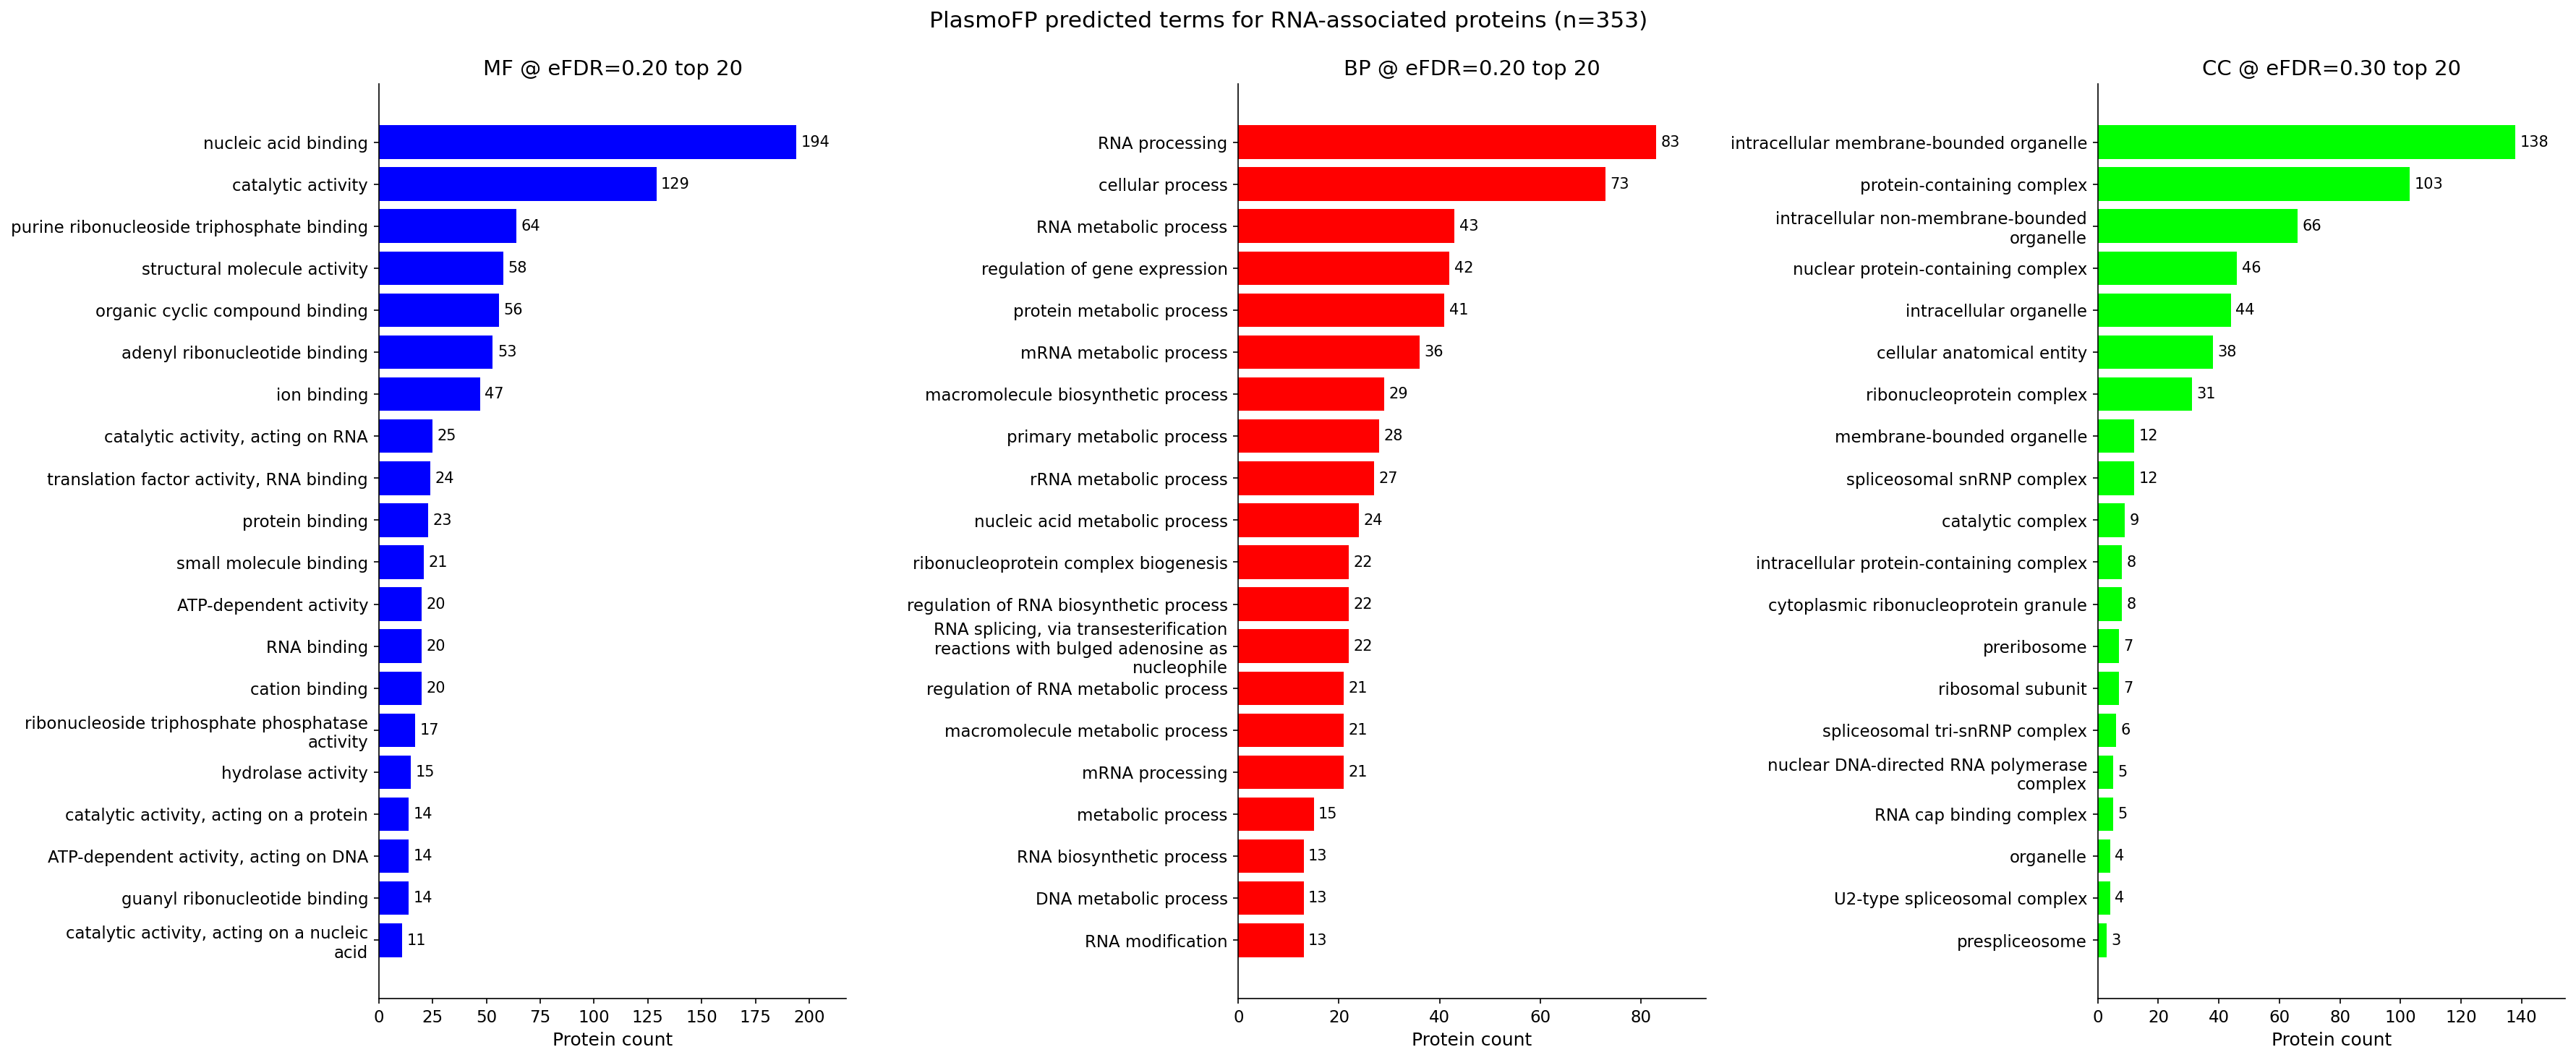

In [ ]:
TARGETS = [("MF", 0.20), ("BP", 0.20), ("CC", 0.30)]
TOP_N   = 20
SHOW_PCT = False         
SHARE_X  = False            
ASP_COLOR = {
    "MF": "#0000FF",  # blue 255
    "BP": "#FF0000",  # red 255
    "CC": "#00FF00",  # green 255
}
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 600,
    "font.size": 15, "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.25,
})

def wrap_label(s: str, width: int = 42) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def count_deepest_terms(deepest_annotations: dict, asp: str, fdr: float) -> Counter:
    ann = deepest_annotations[asp][round(float(fdr), 3)]
    c = Counter()
    for _, triples in ann.items():
        names = {name for _, _, name in triples if name}
        c.update(names)
    return c

def infer_total_proteins(deepest_annotations: dict, asp: str, fdr: float) -> Optional[int]:
    try:
        return len(deepest_annotations[asp][round(float(fdr), 3)])
    except Exception:
        return None


panels = []
for asp, fdr in TARGETS:
    cnt = count_deepest_terms(deepest_annotations, asp, fdr)
    top = cnt.most_common(TOP_N)
    labels = [wrap_label(name) for name, _ in top][::-1]
    values = [v for _, v in top][::-1]
    N_total = infer_total_proteins(deepest_annotations, asp, fdr)
    panels.append((asp, fdr, labels, values, N_total))

fig, axes = plt.subplots(1, 3, figsize=(24, 10))

if SHARE_X:
    common_max = max((max(v) if v else 1) for *_, v, _ in panels) * 1.12

for ax, (asp, fdr, labels_rev, values_rev, N_total) in zip(axes, panels):
    y = np.arange(len(values_rev))
    ax.barh(y, values_rev, color=ASP_COLOR.get(asp, "#4c78a8"), edgecolor="none")
    ax.set_yticks(y)
    ax.set_yticklabels(labels_rev)
    ax.set_xlabel("Protein count")
    ax.set_title(f"{asp} @ eFDR={fdr:.2f} top {TOP_N}")
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)

    xmax = (common_max if SHARE_X else (max(values_rev) if values_rev else 1) * 1.12)
    ax.set_xlim(0, xmax)

    for yy, v in zip(y, values_rev):
        lbl = f"{v}"
        if SHOW_PCT and N_total:
            lbl += f" ({round(100 * v / N_total)}%)"
        ax.text(v + xmax * 0.01, yy, lbl, va="center", ha="left", fontsize=10)

fig.suptitle("PlasmoFP predicted terms for RNA-associated proteins (n=353)", y=0.98, fontsize=15)
fig.tight_layout()
# plt.savefig("deepest_terms_barplots_pubready.png", bbox_inches="tight")
plt.show()
